In [7]:
from Bio.Align import PairwiseAligner, substitution_matrices
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio import SeqIO
import numpy as np
from numpy import random as rd
from matplotlib import pyplot as plt

In [8]:
from src.estimalign import estimalign
from src.logit_link import logit_partial_scores
from src.optimization import create_powerstep, create_constant_step

# Data

In [9]:
from miRBench.dataset import list_datasets, get_dataset_df

In [10]:
hejret_train = get_dataset_df(list_datasets()[0], split="train")
hejret_test = get_dataset_df(list_datasets()[0], split="test")

Using cached dataset /home/mciach/.miRBench/datasets/14501607/AGO2_CLASH_Hejret2023/train/dataset.tsv
Using cached dataset /home/mciach/.miRBench/datasets/14501607/AGO2_CLASH_Hejret2023/test/dataset.tsv


In [11]:
mirlist = hejret_train['noncodingRNA']
mirlist = [Seq(seq) for seq in mirlist]
genelist = hejret_train['gene']
genelist = [Seq(seq).reverse_complement() for seq in genelist]

In [12]:
hejret_train

,gene,noncodingRNA,noncodingRNA_name,noncodingRNA_fam,feature,label,chr,start,end,strand,gene_cluster_ID
0,CCCAGGGTGTTTCATGCTGAGGTAGTAGGATGAATAAAGGCAAATA...,CTATACAATCTACTGTCTTTC,hsa-let-7a-3p,let-7,NaN,1,13,103634174,103634223,-,355
1,CAACTCTATACAACACACCTACTATCTCTTGATGCCCTATTGACAG...,TGAGGTAGTAGGTTGTGTGGTT,hsa-let-7a-5p,let-7,exon,1,10,102362496,102362545,+,1611
2,TAGAGGATCCTAGACCAGCATGCCAGTGTGCCAAGGCCACAGGGAA...,TGAGGTAGTAGGTTGTATAGTT,hsa-let-7a-5p,let-7,exon,1,11,65500706,65500755,+,1457
3,CATCCCCCTGACGGCCGAGAAGCTGTGCATCTACACCGACAACTCC...,TGAGGTAGTAGGTTGTATAGTT,hsa-let-7a-5p,let-7,exon,1,11,69643180,69643229,+,97
4,CAACATGAAACAGTTCATCCGCTACCTCATCTCGTCCAACGTCGGG...,TGAGGTAGTAGGTTGTATAGTT,hsa-let-7a-5p,let-7,exon,1,12,110342392,110342441,+,3303
...,...,...,...,...,...,...,...,...,...,...,...
8188,TGATAGTTCAGCTTGAATGTCTCTTAGAGGGTGGGCTTTTGTTGAT...,CACCCGTAGAACCGACCTTGCG,hsa-miR-99b-5p,mir-10,exon,0,11,65502560,65502609,+,2508
8189,GTGGGACTGCTCTGTCCCCTGCCCCTACTGCAGAGATAGCACTGCC...,CACCCGTAGAACCGACCTTGCG,hsa-miR-99b-5p,mir-10,three_prime_utr,0,17,49053543,49053592,+,239
8190,CCATTTCTTTGGATTTGCCTCTCCTGGACATTTCATATAGATGAAA...,CACCCGTAGAACCGACCTTGCG,hsa-miR-99b-5p,mir-10,intron,0,15,101365823,101365872,-,423
8191,CATCACATGCAGGTGGGCCTGGGCTCCTTGGGAGGAAGTATGGTGG...,CACCCGTAGAACCGACCTTGCG,hsa-miR-99b-5p,mir-10,"intron,exon",0,17,1651376,1651425,-,65


# Optimization

### Simple model on miRNA alignments:

In [13]:
true_match = 1
true_mismatch = -1
true_gapopen = -1.2
true_gapext = -0.1

In [49]:
aligner = PairwiseAligner()
aligner.mode = 'local'
aligner.open_gap_score = true_gapopen
aligner.extend_gap_score = true_gapext
aligner.match = true_match
aligner.mismatch = true_mismatch
# aligner.end_gap_score = 0

In [50]:
mirlist[0]

Seq('CTATACAATCTACTGTCTTTC')

In [51]:
genelist[0]

Seq('TGCATATTTGCCTTTATTCATCCTACTACCTCAGCATGAAACACCCTGGG')

In [52]:
print(next(aligner.align(mirlist[1], genelist[1])))

target            0 ------------------T---GAGGTAGTAGGT-TG-TGT---G-GTT- 22
                  0 ------------------|---|||.||||||||-||-|||---|-|||- 50
query             0 ATCACTGTCAATAGGGCATCAAGAGATAGTAGGTGTGTTGTATAGAGTTG 50



In [9]:
scores = np.array([aligner.score(a, b) for a, b in zip(mirlist, genelist)])

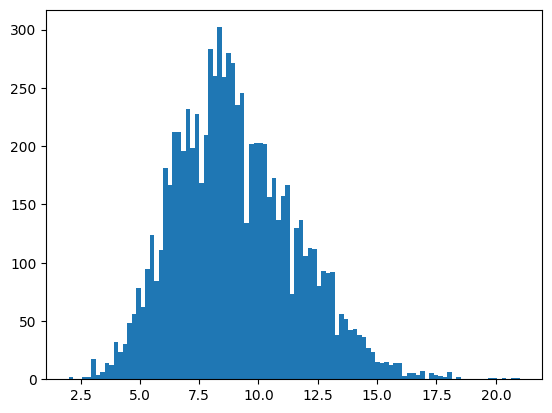

In [10]:
plt.figure()
plt.hist(scores, bins=100)
plt.show()

In [11]:
true_alpha = -9

In [12]:
logit_scores = logit_partial_scores(scores, true_alpha)

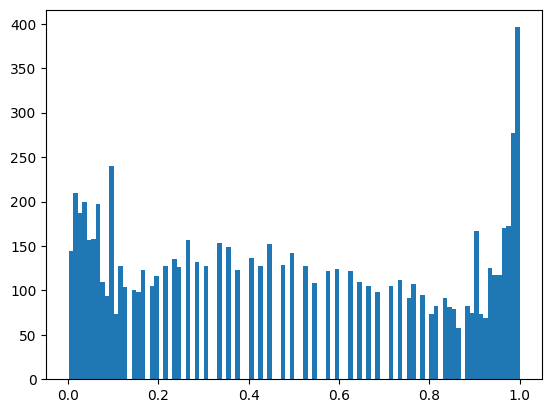

In [13]:
plt.figure()
plt.hist(logit_scores, bins=100)
plt.show()

In [14]:
labels = rd.rand(len(mirlist))
labels = labels <= logit_scores

In [15]:
true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))
print('Sum of log-logit scores:', np.sum(np.log(logit_scores)))
print('True LogL:', true_logL)

Sum of log-logit scores: -10002.78024009512
True LogL: -3281.180240095122


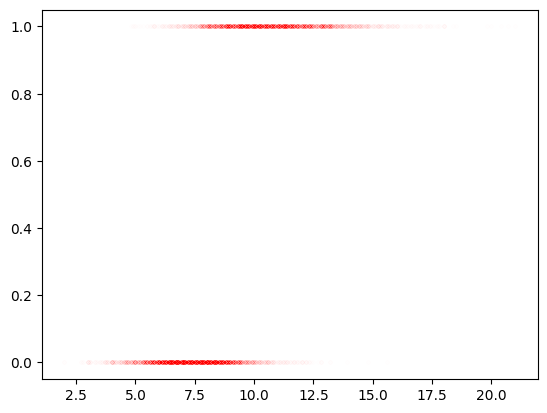

In [16]:
plt.figure()
plt.plot(scores, labels, 'r.', alpha=0.005)

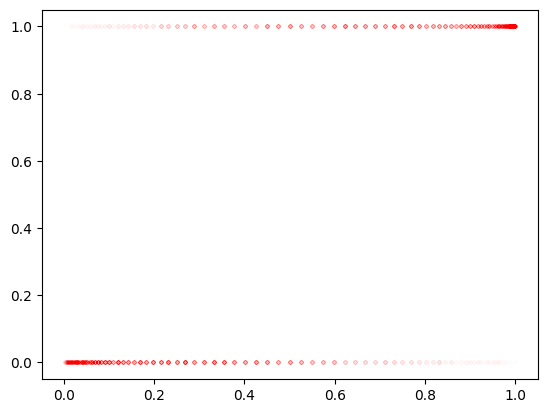

In [17]:
plt.figure()
plt.plot(logit_scores, labels, 'r.', alpha=0.005)

In [58]:
const_step = create_constant_step(0.00005)
# powerstep = create_powerstep(0.00001, power=0.5, burnin=0)
# powerstep = create_powerstep(0.00001, power=-0.5, burnin=0)

In [59]:
NITER = 50

In [63]:
params = estimalign(mirlist, genelist, labels, 
                    stepfunction=const_step,
                    aligner_mode='local',
                    substitution_mode='simple',
                    verbose=True, max_iter=NITER,
                    stochastic_factor=None,
                    num_threads = 16)

Alphabet:
TCAG
Initial parameters:
{'alpha': -8.332389679849879, 'match_score': 0.948882415009223, 'mismatch_score': -0.8288130001069318, 'open_gap_score': -1.1756224866197855, 'extend_gap_score': -0.09881078246342181}
Start of iteration 0
Current alpha: -8.332389679849879
Current logL: -3317.273543611805
Updated alpha: -8.524254799860731
Updated logL: -3296.92443557502
New subgradient:
{'Substitutions': Array([[-34.38840052, -18.41721935,  -3.42507345, -15.18107938],
       [-18.31477721, 192.13554578,  -6.97690127,  -4.73178248],
       [  2.70726021,  -5.9073835 ,  48.76006099, -28.48734126],
       [-14.01654455, -16.49832176, -29.93666318,   0.45111402]],
         alphabet='TCAG'), 'Gap opens': 162.9208446420174, 'Gap extends': 266.0067773680472}
Stepsize: 5e-05
Gap open step: 0.00814604223210087
Gap extend step: 0.01330033886840236
Match step: 0.010347916013346713
Mismatch step: -0.007959291358215053
New parameters:
{'alpha': -8.524254799860731, 'match_score': array([0.95923033])

New subgradient:
{'Substitutions': Array([[-84.50976758, -13.1688491 ,  -1.19822844,  -6.95501347],
       [-12.91703556, 138.92704061,  -5.28101758,   2.00719303],
       [  3.63113637,  -5.98041746,  42.12016276, -22.15262687],
       [ -7.98618545, -10.00464736, -18.29556658, -46.61651647]],
         alphabet='TCAG'), 'Gap opens': 51.49666750858914, 'Gap extends': 103.32837594111592}
Stepsize: 5e-05
Gap open step: 0.0025748333754294574
Gap extend step: 0.005166418797055796
Match step: 0.0024960459658372983
Mismatch step: -0.004915062922965878
New parameters:
{'alpha': -8.927767345811246, 'match_score': array([0.97801206]), 'mismatch_score': array([-0.88417271]), 'open_gap_score': array([-1.14321195]), 'extend_gap_score': array([-0.09727296])}
Subgradient norm: 159.63676155332573
End of iteration 8

Start of iteration 9
Current alpha: -8.927767345811246
Current logL: -3287.8723586841515
Updated alpha: -9.00962794770494
Updated logL: -3284.243011533557
New subgradient:
{'Substitutions

Current alpha: -8.937041357374882
Current logL: -3286.552467617332
Updated alpha: -9.02444373814597
Updated logL: -3282.4304918206744
New subgradient:
{'Substitutions': Array([[-117.5384578 ,   -4.30605712,    4.21043614,    2.76126632],
       [  -8.4039466 ,  128.40297023,    1.07110777,    3.91202058],
       [   5.48269174,   -1.89053745,   29.16905877,  -21.31262422],
       [  -2.80620138,   -8.49507625,  -10.73140736,  -66.26037976]],
         alphabet='TCAG'), 'Gap opens': -23.24321838848333, 'Gap extends': -147.69811346026447}
Stepsize: 5e-05
Gap open step: -0.0011621609194241665
Gap extend step: -0.007384905673013224
Match step: -0.0013113404276481832
Mismatch step: -0.0020254163916950526
New parameters:
{'alpha': -9.02444373814597, 'match_score': array([0.9805865]), 'mismatch_score': array([-0.91295168]), 'open_gap_score': array([-1.13981848]), 'extend_gap_score': array([-0.10745407])}
Subgradient norm: 157.11062991264626
End of iteration 17

Start of iteration 18
Current al

Current alpha: -9.021259814802997
Current logL: -3287.4313848275474
Updated alpha: -8.919198161828975
Updated logL: -3281.8444275295365
New subgradient:
{'Substitutions': Array([[-8.59959926e+01, -4.17010915e+00,  3.57892476e+00,
        -6.30315371e+00],
       [-1.38374632e+01,  1.46286514e+02,  2.28821036e+00,
         9.13898013e+00],
       [ 8.51286631e+00,  7.38138110e-02,  3.80593609e+01,
        -2.07463936e+01],
       [-4.02051000e+00, -7.50466211e+00, -1.02414036e+01,
        -5.67485964e+01]],
         alphabet='TCAG'), 'Gap opens': 14.717078493223044, 'Gap extends': 176.24334923116774}
Stepsize: 5e-05
Gap open step: 0.0007358539246611522
Gap extend step: 0.008812167461558388
Match step: 0.002080064311357273
Mismatch step: -0.002161545000271839
New parameters:
{'alpha': -8.919198161828975, 'match_score': array([0.9840989]), 'mismatch_score': array([-0.93223555]), 'open_gap_score': array([-1.14099515]), 'extend_gap_score': array([-0.09991144])}
Subgradient norm: 186.7562268

Current alpha: -8.91924242317932
Current logL: -3283.726269077143
Updated alpha: -8.991287072524978
Updated logL: -3280.9366888331538
New subgradient:
{'Substitutions': Array([[-112.01528807,   -0.45607992,    4.70149298,   -3.30197404],
       [ -10.96714929,  138.42223527,    2.77602698,    9.92049905],
       [   7.78245129,    4.51933693,   22.31717368,  -22.87526107],
       [  -0.55462682,   -7.40537318,  -10.4277462 ,  -63.4193499 ]],
         alphabet='TCAG'), 'Gap opens': -18.559390895174577, 'Gap extends': -100.99360506193514}
Stepsize: 5e-05
Gap open step: -0.0009279695447587289
Gap extend step: -0.005049680253096757
Match step: -0.000734761450455163
Mismatch step: -0.0013144201646498354
New parameters:
{'alpha': -8.991287072524978, 'match_score': array([0.98448194]), 'mismatch_score': array([-0.94645659]), 'open_gap_score': array([-1.14580874]), 'extend_gap_score': array([-0.10686639])}
Subgradient norm: 107.01022921726339
End of iteration 35

Start of iteration 36
Current 

New subgradient:
{'Substitutions': Array([[-1.02498339e+02, -2.73134946e-02,  5.54324761e+00,
        -3.31554628e+00],
       [-1.02797765e+01,  1.38083719e+02,  4.50401279e+00,
         1.19513920e+01],
       [ 1.00139731e+01,  3.93492967e+00,  2.73113998e+01,
        -2.17246533e+01],
       [ 6.98042570e-01, -7.55735258e+00, -1.06286722e+01,
        -6.23211989e+01]],
         alphabet='TCAG'), 'Gap opens': -12.814607626862497, 'Gap extends': -35.67265974036164}
Stepsize: 5e-05
Gap open step: -0.0006407303813431249
Gap extend step: -0.001783632987018082
Match step: 2.8779046492791594e-05
Mismatch step: -0.0008443858352837047
New parameters:
{'alpha': -8.992705067513448, 'match_score': array([0.98794407]), 'mismatch_score': array([-0.95417547]), 'open_gap_score': array([-1.14969283]), 'extend_gap_score': array([-0.10529092])}
Subgradient norm: 41.5003504867125
End of iteration 43

Start of iteration 44
Current alpha: -8.992705067513448
Current logL: -3280.72440499938
Updated alpha:

In [64]:
print(params['final_loglik'])

-3280.3985416673577


In [61]:
print(params['final_loglik'])

-3280.9204006289506


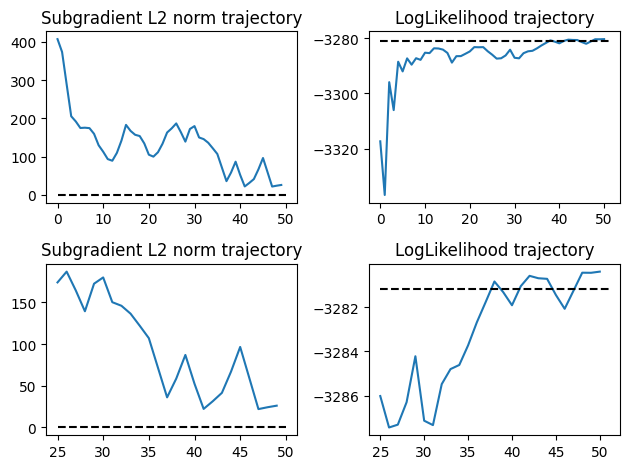

In [67]:
plt.figure()
plt.subplot(221)
plt.plot(np.arange(NITER), params['subgradient_l2_trajectory'])
plt.plot([0, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')


plt.subplot(222)
plt.plot(np.arange(NITER+1), params['loglik_trajectory'])
plt.plot([0, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.subplot(223)
plt.plot(np.arange(NITER//2, NITER), params['subgradient_l2_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')

plt.subplot(224)
plt.plot(np.arange(NITER//2, NITER+1), params['loglik_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.tight_layout()

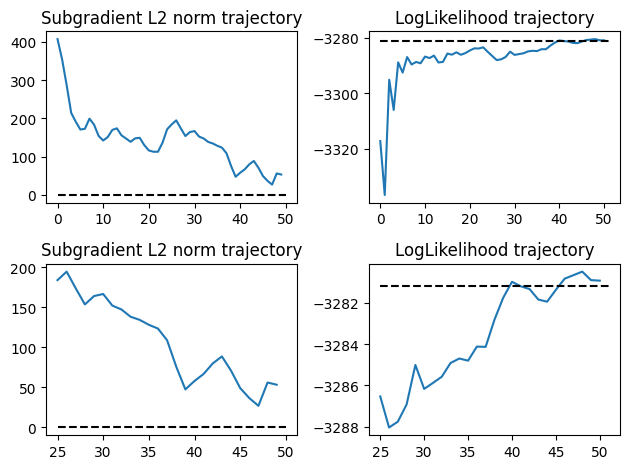

In [62]:
plt.figure()
plt.subplot(221)
plt.plot(np.arange(NITER), params['subgradient_l2_trajectory'])
plt.plot([0, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')


plt.subplot(222)
plt.plot(np.arange(NITER+1), params['loglik_trajectory'])
plt.plot([0, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.subplot(223)
plt.plot(np.arange(NITER//2, NITER), params['subgradient_l2_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')

plt.subplot(224)
plt.plot(np.arange(NITER//2, NITER+1), params['loglik_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.tight_layout()

In [68]:
print(true_match, params['match_score'])
print(true_mismatch, params['mismatch_score'])
print(true_gapopen, params['open_gap_score'])
print(true_gapext, params['extend_gap_score'])
print(true_alpha, params['alpha'])

1 [0.99043018]
-1 [-0.96008404]
-1.2 [-1.15123837]
-0.1 [-0.10372796]
-9 -9.008323871219716


### General matrix, affine gap penalty

In [97]:
true_gapopen = -1.2
true_gapext = -0.1
true_substitution = substitution_matrices.Array(alphabet='ACTG', 
                                          data=np.array([
                                              [1, -0.3, -1, -0.8], 
                                              [-0.6, 1.2, -0.3, -1], 
                                              [-1.2, -0.4, 1, -0.8], 
                                              [-0.4, -1.4, -0.9, 1.3]]))

In [98]:
aligner = PairwiseAligner()
aligner.mode = 'local'
aligner.open_gap_score = true_gapopen
aligner.extend_gap_score = true_gapext
aligner.substitution_matrix = true_substitution

In [99]:
scores = np.array([aligner.score(a, b) for a, b in zip(mirlist, genelist)])

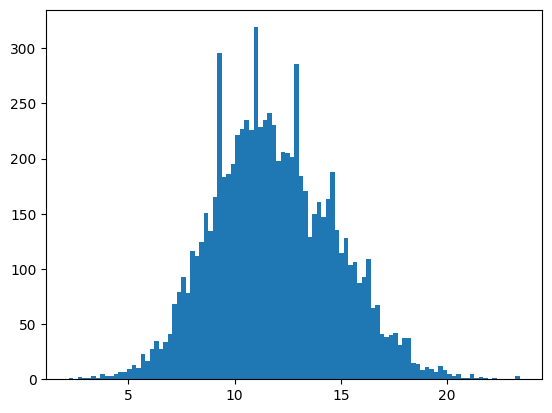

In [100]:
plt.figure()
plt.hist(scores, bins=100)
plt.show()

In [101]:
true_alpha = -12
logit_scores = logit_partial_scores(scores, true_alpha)

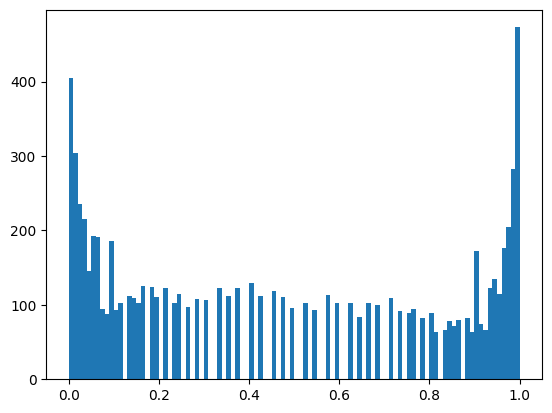

In [102]:
plt.figure()
plt.hist(logit_scores, bins=100)
plt.show()

In [103]:
labels = rd.rand(len(mirlist))
labels = labels <= logit_scores
true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))
print('Sum of log-logit scores:', np.sum(np.log(logit_scores)))
print('True LogL:', true_logL)

Sum of log-logit scores: -11654.43085041492
True LogL: -2958.730850414926


In [104]:
const_step = create_constant_step(0.00005)
# powerstep = create_powerstep(0.00005, power=0.5, burnin=0)
powerstep = create_powerstep(0.00002, power=-0.1, burnin=0)

In [105]:
NITER = 500

In [106]:
params = estimalign(mirlist, genelist, labels, 
                    stepfunction=const_step,
                    aligner_mode='local',
                    substitution_mode='general',
                    gap_mode='affine', 
                    stochastic_factor=0.01,
                    verbose=True, max_iter=NITER,
                    num_threads = 24)

Alphabet:
ATCG
Initial parameters:
{'alpha': -9.519269484600802, 'substitution_matrix': Array([[ 0.86373763, -0.78692338, -0.40140081, -0.67262015],
       [-0.90678335,  0.85002573, -0.35247344, -0.73000227],
       [-0.6677422 , -0.42704254,  1.04723208, -0.82814678],
       [-0.49048558, -0.78369985, -0.84242258,  1.13699792]],
         alphabet='ATCG'), 'open_gap_score': -1.1555138819984556, 'extend_gap_score': -0.09535294913758263}
Start of iteration 0
Current alpha: -9.519269484600802
Current logL: -3044.464826374424
Updated alpha: -9.838467937026605
Updated logL: -2991.752887686305
New subgradient:
{'Substitutions': Array([[ 73.51983012,   8.15249538, -14.36887552, -14.69874069],
       [-28.73900413, 160.11608971,   7.10648079,  -5.62654171],
       [  9.14360215,  13.01574636, 108.91865718, -20.75996442],
       [ -0.63749767, -24.95958854, -30.67482799,  60.01057767]],
         alphabet='ATCG'), 'Gap opens': 181.10715229479268, 'Gap extends': 351.01998045763384}
Stepsize: 5e-

Current alpha: -10.384787265023357
Current logL: -2978.0901145770667
Updated alpha: -10.40990440592399
Updated logL: -2977.7673003968066
New subgradient:
{'Substitutions': Array([[ 37.8019489 ,  11.27892401,  -9.04313254,  -9.01928328],
       [-24.79126982,  55.98765833,   9.56979433,  -0.26479437],
       [ 14.27976437,  21.86165739,  49.32770949, -22.87223892],
       [  4.5224462 , -23.64725885, -29.04189463,  56.50202692]],
         alphabet='ATCG'), 'Gap opens': 34.759777087060634, 'Gap extends': -0.3860321688308903}
Stepsize: 5e-05
Gap open step: 0.0017379888543530319
Gap extend step: -1.9301608441544516e-05
New parameters:
{'alpha': -10.40990440592399, 'substitution_matrix': Array([[ 0.88139256, -0.78236903, -0.40533107, -0.67657315],
       [-0.91708595,  0.88559441, -0.3480343 , -0.73090099],
       [-0.66208466, -0.41918763,  1.0723545 , -0.83702896],
       [-0.48936245, -0.79330423, -0.85368786,  1.16167543]],
         alphabet='ATCG'), 'open_gap_score': array([-1.10898817

Current alpha: -10.61488150797633
Current logL: -2973.5964602395875
Updated alpha: -10.62707614752519
Updated logL: -2973.5211766188513
New subgradient:
{'Substitutions': Array([[ 37.28370651,  11.66908481,  -5.43919832,  -7.93641684],
       [-26.99964313,  39.04192406,  10.5002042 ,   2.14301211],
       [ 12.19012918,  11.52840471,  35.67231036, -20.28138016],
       [  1.38173803, -22.38918231, -25.6507633 ,  37.42128223]],
         alphabet='ATCG'), 'Gap opens': 10.377741330645666, 'Gap extends': 37.349589062268116}
Stepsize: 5e-05
Gap open step: 0.0005188870665322834
Gap extend step: 0.001867479453113406
New parameters:
{'alpha': -10.62707614752519, 'substitution_matrix': Array([[ 0.89564602, -0.77790924, -0.40838979, -0.67964868],
       [-0.92801145,  0.90168792, -0.34337195, -0.73048753],
       [-0.65693449, -0.41314575,  1.08795925, -0.84536952],
       [-0.48786801, -0.80220256, -0.86497699,  1.17818253]],
         alphabet='ATCG'), 'open_gap_score': array([-1.10679128]), '

Current alpha: -10.806695685462502
Current logL: -2970.8054082316203
Updated alpha: -10.82339313095321
Updated logL: -2970.6651594172577
New subgradient:
{'Substitutions': Array([[ 27.51657961,  12.52866634,  -4.26042329,  -5.43037369],
       [-26.99872972,  29.82852958,  10.88796323,   1.04917329],
       [  9.76504823,  11.52521634,  27.77599425, -17.92673337],
       [  8.95102404, -20.88226752, -27.62451121,  28.99667829]],
         alphabet='ATCG'), 'Gap opens': -5.448446182555981, 'Gap extends': -14.780501287571367}
Stepsize: 5e-05
Gap open step: -0.00027242230912779907
Gap extend step: -0.0007390250643785684
New parameters:
{'alpha': -10.82339313095321, 'substitution_matrix': Array([[ 0.90795219, -0.77309488, -0.41031776, -0.68221383],
       [-0.93848   ,  0.91431936, -0.33871819, -0.73019971],
       [-0.65299104, -0.40845962,  1.10104212, -0.85279618],
       [-0.48499472, -0.81052955, -0.87611821,  1.19005734]],
         alphabet='ATCG'), 'open_gap_score': array([-1.1082629

Current alpha: -10.938818713164556
Current logL: -2969.077153993493
Updated alpha: -10.9750109686695
Updated logL: -2968.421874269075
New subgradient:
{'Substitutions': Array([[ 20.57227284,  10.81128628,  -5.7928953 ,  -4.70892073],
       [-24.19472989,  21.36502533,   8.54567958,   1.25815538],
       [ 10.36289232,  12.75159615,  20.29926237, -16.47428423],
       [ 10.08919893, -20.50852816, -29.19035945,  20.23929723]],
         alphabet='ATCG'), 'Gap opens': -19.342321066360107, 'Gap extends': -41.5323358019914}
Stepsize: 5e-05
Gap open step: -0.0009671160533180054
Gap extend step: -0.0020766167900995703
New parameters:
{'alpha': -10.9750109686695, 'substitution_matrix': Array([[ 0.91821881, -0.76862384, -0.41224947, -0.68470048],
       [-0.94887873,  0.92391347, -0.33539561, -0.7294926 ],
       [-0.64899924, -0.40332707,  1.11084692, -0.85954533],
       [-0.48116683, -0.81865189, -0.88768968,  1.20134636]],
         alphabet='ATCG'), 'open_gap_score': array([-1.11214706]), '

...

Current alpha: -11.943464397573349
Current logL: -2949.7859433458343
Updated alpha: -11.942326530961534
Updated logL: -2949.7853309023267
New subgradient:
{'Substitutions': Array([[ 1.0494999 , -0.41901304,  0.58199704, -3.30102724],
       [-6.53671595, -1.41594318,  0.37331857, -0.38532889],
       [-0.28425658,  0.5366865 , -0.47118703, -5.6255324 ],
       [ 0.29810029, -4.61665453, -9.00794163, -0.82657286]],
         alphabet='ATCG'), 'Gap opens': -2.425861966735445, 'Gap extends': -12.672002855501866}
Stepsize: 5e-05
Gap open step: -0.00012129309833677224
Gap extend step: -0.0006336001427750933
New parameters:
{'alpha': -11.942326530961534, 'substitution_matrix': Array([[ 1.00451672, -0.716249  , -0.4576007 , -0.76366578],
       [-1.17249195,  1.01004254, -0.31623036, -0.73260821],
       [-0.61570941, -0.36816238,  1.19811229, -1.04455254],
       [-0.48057924, -0.98660977, -1.24274756,  1.29702766]],
         alphabet='ATCG'), 'open_gap_score': array([-1.223558]), 'extend_gap

Current alpha: -11.949591952704122
Current logL: -2949.7494049998704
Updated alpha: -11.941283368239313
Updated logL: -2949.7167581874687
New subgradient:
{'Substitutions': Array([[ 0.4517027 , -0.37510251,  0.88892396, -2.76669607],
       [-5.69458022, -1.40417972,  0.35535028, -0.61667058],
       [-0.58328531,  0.42189482,  0.89077688, -5.87291164],
       [ 0.32773272, -4.49548427, -8.38597375,  0.54368532]],
         alphabet='ATCG'), 'Gap opens': -1.4377370774065201, 'Gap extends': -12.22688935170032}
Stepsize: 5e-05
Gap open step: -7.1886853870326e-05
Gap extend step: -0.0006113444675850161
New parameters:
{'alpha': -11.941283368239313, 'substitution_matrix': Array([[ 1.00491691, -0.71650573, -0.45751518, -0.76471721],
       [-1.17475605,  1.0101871 , -0.31633098, -0.73274186],
       [-0.61600421, -0.36789002,  1.19832787, -1.04680788],
       [-0.48080676, -0.98835636, -1.24631886,  1.29697723]],
         alphabet='ATCG'), 'open_gap_score': array([-1.22399784]), 'extend_gap_

Current alpha: -11.932020629608132
Current logL: -2950.1949181321643
Updated alpha: -11.963124316860203
Updated logL: -2949.7368067565876
New subgradient:
{'Substitutions': Array([[-4.51774825,  0.18250405,  1.32874546, -2.245578  ],
       [-5.69989573, -6.71152406, -1.60243292,  0.9785389 ],
       [-0.80204476, -0.4844486 , -0.02969894, -5.26083257],
       [-1.11315376, -4.19246024, -8.54229889,  2.18923227]],
         alphabet='ATCG'), 'Gap opens': -7.249189242598774, 'Gap extends': -61.716577004722865}
Stepsize: 5e-05
Gap open step: -0.00036245946212993873
Gap extend step: -0.0030858288502361433
New parameters:
{'alpha': -11.963124316860203, 'substitution_matrix': Array([[ 1.0051063 , -0.7169335 , -0.45734719, -0.76573768],
       [-1.17698987,  1.01014861, -0.31656631, -0.73284789],
       [-0.61636908, -0.36782411,  1.19852541, -1.04901804],
       [-0.48094055, -0.9901198 , -1.24978292,  1.29734947]],
         alphabet='ATCG'), 'open_gap_score': array([-1.2241892]), 'extend_ga

Current alpha: -11.942642791068188
Current logL: -2949.6219939650664
Updated alpha: -11.934094499339007
Updated logL: -2949.5874572204293
New subgradient:
{'Substitutions': Array([[ 2.55115724e+00, -9.81952919e-01, -6.54942072e-01,
        -2.03249223e+00],
       [-5.48638123e+00,  5.21849190e+00, -8.16390830e-02,
        -1.17356324e+00],
       [-1.03735267e+00,  2.29518865e-01,  1.64085279e+00,
        -5.59533416e+00],
       [-4.18688616e-01, -4.66434676e+00, -8.63601414e+00,
        -3.06224401e-03]],
         alphabet='ATCG'), 'Gap opens': 4.35256014888126, 'Gap extends': 41.36157299428287}
Stepsize: 5e-05
Gap open step: 0.000217628007444063
Gap extend step: 0.0020680786497141433
New parameters:
{'alpha': -11.934094499339007, 'substitution_matrix': Array([[ 1.00546753, -0.71713899, -0.45727165, -0.76661856],
       [-1.17930495,  1.01085418, -0.31659137, -0.73308407],
       [-0.61668066, -0.36771003,  1.1987273 , -1.0512079 ],
       [-0.48111562, -0.99177141, -1.25323939,  1.

Current alpha: -11.934977216273422
Current logL: -2949.7598014189684
Updated alpha: -11.955412472287458
Updated logL: -2949.562201149697
New subgradient:
{'Substitutions': Array([[-1.22963831, -0.0675355 ,  1.14301874, -2.01607305],
       [-5.50066643, -6.55062099, -1.79519221,  1.15466867],
       [-0.73134586,  0.30496362, -0.39026197, -4.85033753],
       [-0.91794607, -3.89563254, -7.53491204,  3.70536551]],
         alphabet='ATCG'), 'Gap opens': -5.022911479193098, 'Gap extends': -49.888007464719685}
Stepsize: 5e-05
Gap open step: -0.0002511455739596549
Gap extend step: -0.0024944003732359846
New parameters:
{'alpha': -11.955412472287458, 'substitution_matrix': Array([[ 1.00560862, -0.71726108, -0.45711268, -0.76745071],
       [-1.18169915,  1.01080835, -0.31680408, -0.7331804 ],
       [-0.61698696, -0.36763507,  1.19888332, -1.05340071],
       [-0.48133096, -0.99331539, -1.25650973,  1.2974348 ]],
         alphabet='ATCG'), 'open_gap_score': array([-1.22483953]), 'extend_gap

In [107]:
print(params['final_loglik'])

-2949.4859835909674


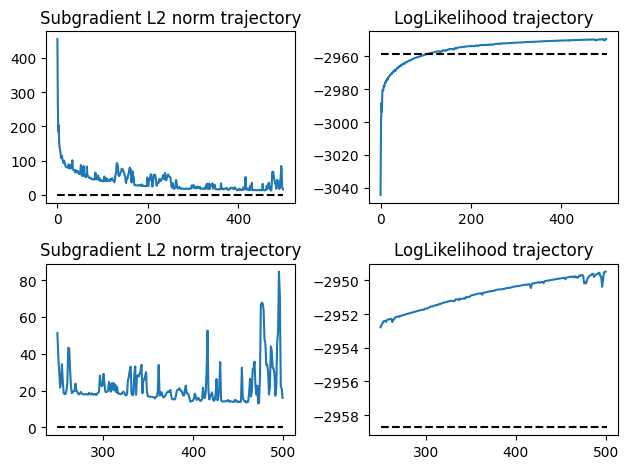

In [108]:
plt.figure()
plt.subplot(221)
plt.plot(np.arange(NITER), params['subgradient_l2_trajectory'])
plt.plot([0, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')


plt.subplot(222)
plt.plot(np.arange(NITER+1), params['loglik_trajectory'])
plt.plot([0, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')


plt.subplot(223)
plt.plot(np.arange(NITER//2, NITER), params['subgradient_l2_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')

plt.subplot(224)
plt.plot(np.arange(NITER//2, NITER+1), params['loglik_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.tight_layout()

In [109]:
print(true_gapopen, params['open_gap_score'])
print(true_gapext, params['extend_gap_score'])
print(true_alpha, params['alpha'])
true_subs_vector = []
param_subs_vector = []
for char1 in true_substitution.alphabet:
    for char2 in true_substitution.alphabet:
        true_v = true_substitution[char1, char2]
        true_subs_vector.append(true_v)
        estim_v = params['substitution_matrix'][char1, char2]
        param_subs_vector.append(estim_v)
        print(char1, char2, true_v, estim_v)
        
print(np.corrcoef(true_subs_vector, param_subs_vector))
print(np.mean(np.abs(np.array(true_subs_vector)- np.array(param_subs_vector))))

-1.2 [-1.224788]
-0.1 [-0.09878584]
-12 -11.940378677961673
A A 1.0 1.0057685613824001
A C -0.3 -0.4570780813619056
A T -1.0 -0.7175408257188391
A G -0.8 -0.7679236157416713
C A -0.6 -0.6172144696952062
C C 1.2 1.1991189652631504
C T -0.3 -0.3675682136816867
C G -1.0 -1.054833241765892
T A -1.2 -1.1830481144721774
T C -0.4 -0.31701749680268854
T T 1.0 1.0110175433354485
T G -0.8 -0.733332686261473
G A -0.4 -0.4814151059244651
G C -1.4 -1.258489665165457
G T -0.9 -0.9943151590486898
G G 1.3 1.2975421414550101
[[1.         0.99351278]
 [0.99351278 1.        ]]
0.06969980408220171


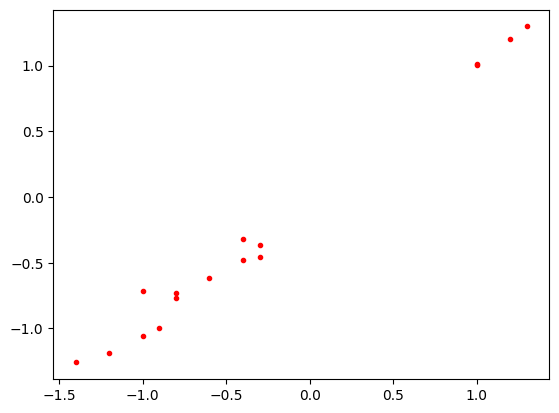

In [111]:
plt.figure()
plt.plot(true_subs_vector, param_subs_vector, 'r.')

# Proteins

### Simulated alignments

In [339]:
blosum62 = substitution_matrices.load('BLOSUM62')

In [351]:
coupling = 2**blosum62/(len(blosum62.alphabet)**2)
coupling /= np.sum(coupling)

In [355]:
aa_pairs = [(char1, char2) for char1 in blosum62.alphabet for char2 in blosum62.alphabet]
prob_vect = [coupling[aapair] for aapair in aa_pairs]

In [363]:
for aa, prob in zip(aa_pairs, prob_vect):
    print(aa, prob)

('A', 'A') 0.003933257536182897
('A', 'R') 0.00012291429800571552
('A', 'N') 6.145714900285776e-05
('A', 'D') 6.145714900285776e-05
('A', 'C') 0.00024582859601143104
('A', 'Q') 0.00012291429800571552
('A', 'E') 0.00012291429800571552
('A', 'G') 0.00024582859601143104
('A', 'H') 6.145714900285776e-05
('A', 'I') 0.00012291429800571552
('A', 'L') 0.00012291429800571552
('A', 'K') 0.00012291429800571552
('A', 'M') 0.00012291429800571552
('A', 'F') 6.145714900285776e-05
('A', 'P') 0.00012291429800571552
('A', 'S') 0.0004916571920228621
('A', 'T') 0.00024582859601143104
('A', 'W') 3.072857450142888e-05
('A', 'Y') 6.145714900285776e-05
('A', 'V') 0.00024582859601143104
('A', 'B') 6.145714900285776e-05
('A', 'Z') 0.00012291429800571552
('A', 'X') 0.00024582859601143104
('A', '*') 1.536428725071444e-05
('R', 'A') 0.00012291429800571552
('R', 'R') 0.007866515072365793
('R', 'N') 0.00024582859601143104
('R', 'D') 6.145714900285776e-05
('R', 'C') 3.072857450142888e-05
('R', 'Q') 0.0004916571920228

In [353]:
SETSIZE = 5000

In [359]:
Alist = []
Blist = []
for _ in range(SETSIZE):
    pairs = rd.choice(len(aa_pairs), p=prob_vect, replace=True, size=250)
    pairs = [aa_pairs[i] for i in pairs]
    aseq = ''.join(x[0] for x in pairs)
    bseq = ''.join(x[1] for x in pairs)
    Alist.append(aseq)
    Blist.append(bseq)

In [361]:
Blist

['CLWHWMHDWWHWWWWCHCWCCHYWCKFWHWWWYNHCWWWIWWWWCWWWWWCYDCCWWWWHCSTGWCWQYRYWWWWEHFWCWWPWBHCCILNWMPWCWYWEIHHWNQCWCPYWWWGWCWWNWWWWYWWCWWPCWNQXIZNFCPWCWWWWCWRCFYWCWWGWWCCWWQWNWWCCWQBEYWEWWMWWWCWEWWWYWWWWDVWYCVZZCWPCWWCWWEPWWWGWZMDWHFWWQWPCWCHWWWCWWWCWWWCQWW',
 'WWWDWCZYWWRBHWHHCWKWWWHWWWWWCYWTWHEWWNWVWGWCWHWWYFWWLWWGWHCQBCNFWYWWHTWWPDWWDWHCWCWWSWWWHSBWWWPWWNBZWYHWWWWQHYWTZWWWCRFWWWPWWWCWWHWWWWYHWMGCCCCQHPWWWYLYWWWWWWPWWZWCQWCWGQWHWHYWKWEWPWWPWCCCCWWWWWWYRWCWEWCHYWWWZWWCWWPCWWWWWCWCCWYGWWWWWWCWWWWIWWHWCWFZPH',
 'NWHWWCWNWWWWLWWWWHWWWHWWWWCWWWWCQTWWNCWWVWWDYWFCWCDWCCGHCRWWWCWWQHWCDDWYWDWRAWDWWWWWCCGPLPLWWWWNWZKWWTTWWGWCCYWCWCEWWNKWBCHWYYWWWBWWZWWWWWWWWWWWWAPWCCNYWHLHWNWCWWEYNWYCWCWWWHHWWWKWWWDWDTWWWWFCWHAWWWPCWHWBHWEVWHVLCCHCWWWWWPCYKEHWWGWWDMWWDWWCWWYWHWWMPF',
 'WWWMWWHCWCWHFWCFHWCPWYCWWHWKWWWWWWWYCAWWRWHHWWBWHWWFFWHWWWPWWWWWPWVDWWQWNHWNQFNWQWWBHWCWPWXWWHWCCCHWEYDHCWYCWCWNWHWFWCWZWWWSPWWWDWWGWWYWWWWHHGHWWWWWWHWPCWCHCAWWWWTWCWWHWWAKWPWWHNPBVWCWHWWHWWAKNWWWWHWWCWPZWKBPPTWWWWWFDHWWIMCSWPZWHWWWE

### Symmetric matrix on protein alignments:

In [112]:
positive_id_tuples = []
close_negative_id_tuples = []
with open('./Proteomes/human_to_chicken_upto1000aa.blast') as h:
    for l in h:
        l = l.split('\t')
        evalue = float(l[-2])
        if evalue == 0:
            positive_id_tuples.append([l[0], l[1]])
        elif evalue > 0.0001:
            close_negative_id_tuples.append([l[0], l[1]])

In [113]:
human_proteome = list(SeqIO.parse('Proteomes/GCF_000001405.40/up_to_1000.faa', 'fasta'))
chick_proteome = list(SeqIO.parse('Proteomes/GCF_016699485.2/up_to_1000.faa', 'fasta'))

In [121]:
alphabet = 'ACDEFGHIKLMNPQRSTVWY'

In [122]:
human_proteome = [seq for seq in human_proteome if set(str(seq.seq)).issubset(set(alphabet))]
chick_proteome = [seq for seq in chick_proteome if set(str(seq.seq)).issubset(set(alphabet))]

In [124]:
human_prot_ids = [seq.id for seq in human_proteome]
chick_prot_ids = [seq.id for seq in chick_proteome]

In [130]:
human_prot_ids_set = set(human_prot_ids)
chick_prot_ids_set = set(chick_prot_ids)

In [131]:
positive_id_tuples = [t for t in positive_id_tuples if t[0] in human_prot_ids_set and t[1] in chick_prot_ids_set]
# close_negative_id_tuples = [t for t in close_negative_id_tuples if t[0] in human_prot_ids_set and t[1] in chick_prot_ids_set]

In [286]:
SETSIZE = 5000

In [287]:
# pos_set = rd.choice(len(positive_id_tuples), SETSIZE//2, replace=False)
# neg_set = rd.choice(len(close_negative_id_tuples), SETSIZE//2, replace=False)
# prot_dset = [positive_id_tuples[i] for i in pos_set] + [close_negative_id_tuples[i] for i in neg_set]
pos_set = rd.choice(len(positive_id_tuples), SETSIZE, replace=False)
prot_dset = [positive_id_tuples[i] for i in pos_set]

In [288]:
human_list = [human_proteome[human_prot_ids.index(hpid)] for hpid, cpid in prot_dset]
chick_list = [chick_proteome[chick_prot_ids.index(cpid)] for hpid, cpid in prot_dset]

In [289]:
blosum62 = substitution_matrices.load('BLOSUM62')

In [290]:
blosum62 /= np.sqrt(np.sum(blosum62**2))

In [293]:
aligner = PairwiseAligner()
aligner.mode = 'global'
aligner.substitution_matrix=blosum62
aligner.open_gap_score = -1
aligner.extend_gap_score = -0.1

Example scores of alignments to visualize gap open and extend penalties for global alignment:

In [294]:
test_aln = aligner.align('ATA', 'AA')
print(next(test_aln))
print(2*blosum62['A', 'A'] - 1, test_aln.score)
test_aln = aligner.align('ATTA', 'AA')
print(next(test_aln))
print(2*blosum62['A', 'A'] - 1 - 0.1, test_aln.score)

target            0 ATA 3
                  0 |-| 3
query             0 A-A 2

-0.866998755185649 -0.8669987551856488
target            0 ATTA 4
                  0 |--| 4
query             0 A--A 2

-0.9669987551856489 -0.9669987551856489


In [295]:
scores = np.array([aligner.score(a, b) for a, b in zip(human_list, chick_list)])

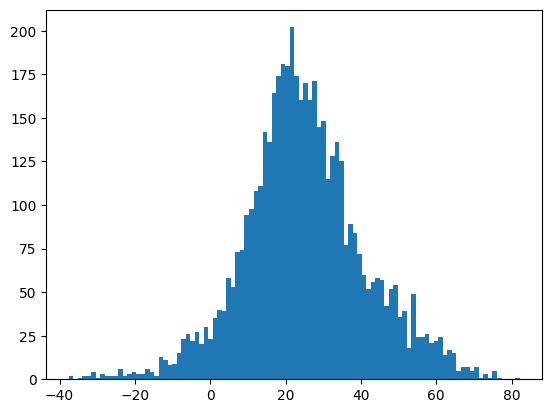

In [296]:
plt.figure()
plt.hist(scores, bins=100)
plt.show()

In [297]:
print(next(aligner.align(human_list[0], chick_list[0])))

XP_047305         0 MWRECDWGLGAVKSDLACVPSAKRLLCRMSNKDRHIDSSCSSFIKTEPSSPASLTDSVNH
                  0 ----------------------------||.|||||||||||.||||||||||||||.||
NP_001383         0 ----------------------------MSSKDRHIDSSCSSYIKTEPSSPASLTDSINH

XP_047305        60 HSPGGSSDASGSYSSTMNGHQNGLDSPPLYPSAPILGGSGPVRKLYDDCSSTIVEDPQTK
                 60 |||||||||||||||||||||||||||||||||..|||.|||||.||||||||.||.|||
NP_001383        32 HSPGGSSDASGSYSSTMNGHQNGLDSPPLYPSATGLGGNGPVRKRYDDCSSTIAEDSQTK

XP_047305       120 CEYMLNSMPKRLCLVCGDIASGYHYGVASCEACKAFFKRTIQGNIEYSCPATNECEITKR
                120 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
NP_001383        92 CEYMLNSMPKRLCLVCGDIASGYHYGVASCEACKAFFKRTIQGNIEYSCPATNECEITKR

XP_047305       180 RRKSCQACRFMKCLKVGMLKEGVRLDRVRGGRQKYKRRIDAENSPYLNPQLVQPAKKPLL
                180 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||.-
NP_001383       152 RRKSCQACRFMKCLKVGMLKEGVRLDRVRGGRQKYKRRIDAENSPYLNPQLVQPAKKPY-

XP_047305       240 WSDP

In [299]:
logit_scores = logit_partial_scores(scores, -20)

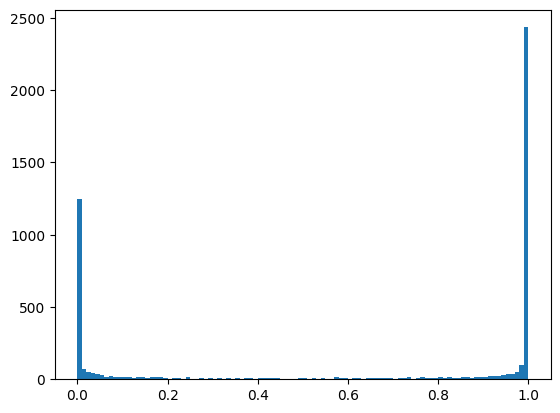

In [300]:
plt.figure()
plt.hist(logit_scores, bins=100)
plt.show()

Expectation check:

In [301]:
logL_distribution = []
for _ in range(5000):
    labels = rd.rand(len(human_list))
    labels = labels <= logit_scores
    true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))
    logL_distribution.append(true_logL)

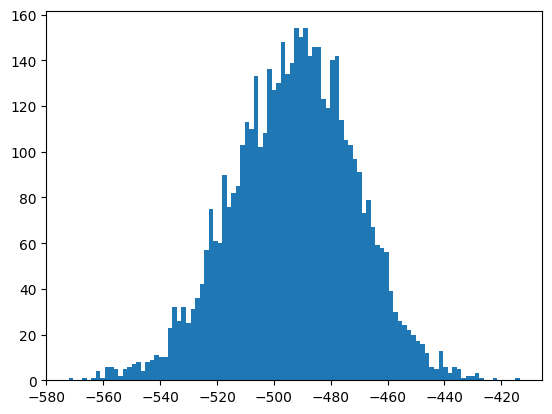

In [302]:
plt.figure()
plt.hist(logL_distribution, bins=100)
plt.show()

In [303]:
EL = 0 
VL = 0
for ls in logit_scores:
    if 1e-24 < ls < 1-1e-24:
        EL += ls*np.log(ls) + (1-ls)*np.log(1-ls)
        VL += ls*(1-ls)*(np.log(ls)**2 + np.log(1-ls)**2) # Incorrect
SDL = np.sqrt(VL)

In [304]:
print('Expected LogL:', EL)
print('Average LogL:', np.mean(logL_distribution))
print('STD LogL:', SDL)
print('Sample STD:', np.std(logL_distribution))

Expected LogL: -492.961331556755
Average LogL: -492.83136372138114
STD LogL: 23.83982117588265
Sample STD: 21.590079372381034


Fitting:

In [321]:
labels = rd.rand(len(human_list))
labels = labels <= logit_scores

In [322]:
true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))

In [323]:
print('Sum of log-logit scores:', np.sum(np.log(logit_scores)))
print('True LogL:', true_logL)

Sum of log-logit scores: -19494.686981856918
True LogL: -473.3818560942222


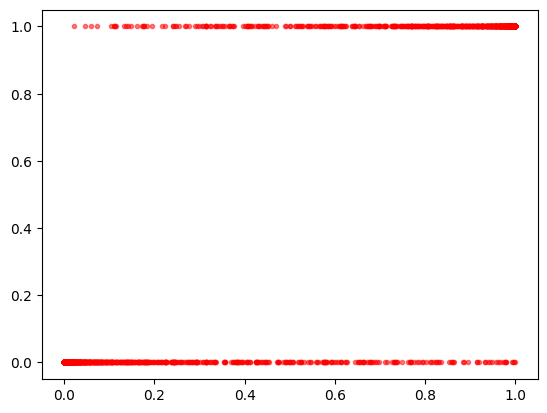

In [324]:
plt.figure()
plt.plot(logit_scores, labels, 'r.', alpha=0.5)

In [325]:
const_step = create_constant_step(0.00005)
powerstep = create_powerstep(0.000005, power=0.5, burnin=0) # step 0.00005 good for SETSIZE==1000
# powerstep = create_powerstep(0.0000001, power=-0.5, burnin=0)

In [326]:
NITER = 50

In [327]:
set('WEIMFASVCGKLTHDPRNQY') == set(alphabet) 

True

In [328]:
params = estimalign(human_list, chick_list, labels, 
                    stepfunction=powerstep,
                    aligner_mode='global',
                    substitution_mode='general',
                    gap_mode='affine',
                    baseline_aligner=aligner,
                    stochastic_factor=0.0001,
                    verbose=True, max_iter=NITER,
                    num_threads = 16)

Alphabet:
WEIMFASVCGKLTHDPRNQY
Initial parameters:
{'alpha': -35.101053302810854, 'substitution_matrix': Array([[ 3.48825056e-01,  5.99924929e-01,  4.17629018e-01,
        -3.73187553e-01,  2.80712973e-01, -1.92579665e-01,
         3.63649868e-01,  9.24646410e-02, -1.82697874e-01,
        -6.20571638e-01, -1.54715365e-02,  6.81000778e-01,
         1.58561460e-01, -4.91615555e-01,  1.05286898e-03,
        -2.14071773e-01, -1.38160217e-01, -1.69362192e-01,
         6.91424458e-01, -3.87961231e-01],
       [-4.95390953e-01,  1.48953091e-01, -6.88399086e-02,
         6.09065215e-01, -1.43467004e+00,  9.93699223e-02,
        -4.62401007e-02,  1.67419103e-01,  3.88079948e-01,
        -3.55739288e-01,  8.98176490e-02, -1.61843964e-01,
         5.73399833e-01, -2.31427963e-01,  2.02452881e-01,
        -4.76874094e-01,  1.77812210e-01, -3.45593184e-01,
         1.37161711e-01, -8.47186878e-01],
       [-6.42274608e-01, -3.10288428e-01,  8.40838074e-02,
        -1.61377649e-01, -5.64385627e-02, 

New subgradient:
{'Substitutions': Array([[  -47.7684489 ,  -220.26929544,  -105.50773594,    -7.01214256,
          -76.02983061,   -48.78249437,  -235.7573384 ,   -58.36578767,
          -23.66710737,   -20.75172482,   -64.13234295,  -355.91045585,
          -59.92653873,   -15.91732101,   -50.2415697 ,   -51.44503821,
          -63.43606471,   -33.60601043,  -137.97632614,   -25.39556852],
       [  -37.92136608,   300.20734013,  -419.0900276 ,  -350.36591961,
          -17.5241978 ,  -816.83883446,  -969.46281793,  -683.13555567,
         -360.16776974,  -393.19380616,  -988.96160533,  -683.01656583,
        -1334.22180537,  -198.47670639, -1120.94709794,  -266.75772339,
         -815.70393392,  -212.55428739,  -812.58635283,   -51.66071017],
       [   -6.6143843 ,  -256.48534313,  2052.87193971,   -82.52483079,
         -177.22355121,  -297.61798522,  -906.77248257,  -559.26583523,
         -261.07693898,  -234.33267272,  -762.34928305,  -765.73498853,
         -210.48352036,   -

Current alpha: -44.71348152155573
Current logL: -3505.7510822265153
Updated alpha: -43.1292506112052
Updated logL: -3388.4070515014323
New subgradient:
{'Substitutions': Array([[  -53.20560113,  -152.01484423,   -85.5844822 ,    -5.66701974,
          -68.01529743,   -35.19542024,  -186.99831358,   -43.75809394,
          -21.2496579 ,   -13.12832326,   -52.31956948,  -286.1127478 ,
          -47.50177923,   -11.66927393,   -38.17740963,   -48.01508159,
          -55.94891913,   -37.11826284,  -108.94376676,   -22.45866758],
       [  -31.59055768,   736.83634036,  -335.64745037,  -272.08460854,
          -14.95851692,  -596.00656909,  -795.15038398,  -484.64846039,
         -279.33113581,  -301.39801595,  -775.00494578,  -536.46228434,
        -1010.90647842,  -164.76315726,  -952.71081789,  -201.71481495,
         -614.4779133 ,  -212.35452842,  -637.71931093,   -48.61404158],
       [  -14.27648429,  -183.97067938,  1608.88968224,   -94.3217098 ,
         -151.40050126,  -236.260194

Current alpha: -43.1292506112052
Current logL: -3070.471051749851
Updated alpha: -44.014290906156965
Updated logL: -3033.946813148275
New subgradient:
{'Substitutions': Array([[  -90.36934652,  -147.63233416,   -75.56851525,    -5.69173944,
          -62.16621248,   -35.72769956,  -170.68856639,   -37.3721081 ,
          -21.43247823,   -11.79414617,   -42.30508789,  -265.29976508,
          -46.87511073,   -12.01609914,   -31.00447709,   -46.93150341,
          -56.60839937,   -34.73134572,   -98.96505641,   -20.43495507],
       [  -31.13127624,   471.14531503,  -317.42538295,  -261.43425368,
          -11.69819919,  -563.09332249,  -745.90558167,  -450.37239384,
         -256.96389771,  -275.33759425,  -718.45987   ,  -485.29956995,
         -942.5116009 ,  -153.3570828 ,  -896.05923611,  -197.69346339,
         -579.68834565,  -197.87764187,  -597.27365416,   -45.77458957],
       [  -14.13314041,  -168.17733147,  1383.1626053 ,   -89.25144306,
         -135.57356892,  -214.5518444

Current alpha: -44.014290906156965
Current logL: -2805.9280024074606
Updated alpha: -44.47376231668779
Updated logL: -2796.1207759285717
New subgradient:
{'Substitutions': Array([[ -101.75583512,  -139.01518046,   -69.76756237,    -5.1469448 ,
          -58.72116187,   -32.81877711,  -155.85020182,   -34.19291107,
          -20.82554237,   -11.29088776,   -38.77806948,  -249.18328973,
          -43.68358786,   -12.4438557 ,   -29.26041433,   -44.66453717,
          -56.7908306 ,   -33.13982218,   -94.91712889,   -19.58600908],
       [  -30.2891651 ,   339.21794619,  -304.27578326,  -245.46480888,
          -10.93863475,  -529.5964806 ,  -707.45572374,  -432.32703362,
         -243.17843594,  -260.51530445,  -686.60446559,  -461.88619459,
         -902.88738297,  -143.68765172,  -850.62491292,  -184.2026764 ,
         -550.19137291,  -187.25120862,  -563.37485751,   -41.49460719],
       [  -13.4665538 ,  -161.7908409 ,  1250.22637714,   -82.939515  ,
         -125.60492622,  -202.7828

...

Current alpha: -44.70738675453603
Current logL: -1248.8386690306484
Updated alpha: -44.67863961868739
Updated logL: -1248.8033507463783
New subgradient:
{'Substitutions': Array([[-9.28262007e+01, -6.71117100e+01, -3.77522565e+01,
        -1.89249106e+00, -1.98037139e+01, -1.30017038e+01,
        -5.66032547e+01, -1.25722286e+01, -5.05421966e+00,
        -1.04468174e+01, -1.71512677e+01, -1.02074141e+02,
        -2.09934156e+01, -4.13199702e+00, -1.35701939e+01,
        -1.67748324e+01, -3.12441001e+01, -1.48056637e+01,
        -4.07637235e+01, -4.95583212e+00],
       [-1.61182981e+01, -1.53148963e+02, -1.55473926e+02,
        -9.35599176e+01, -2.11896849e+00, -2.12939077e+02,
        -3.07878615e+02, -1.94625065e+02, -1.01601023e+02,
        -1.23856784e+02, -3.14786055e+02, -1.91308576e+02,
        -4.37987098e+02, -6.14777531e+01, -3.47580096e+02,
        -7.11642478e+01, -2.72259566e+02, -9.45376463e+01,
        -2.19417445e+02, -2.23532690e+01],
       [-5.78865658e+00, -8.2336547

Current alpha: -44.67863961868739
Current logL: -1240.6699287786155
Updated alpha: -44.650790559668316
Updated logL: -1240.6368596874354
New subgradient:
{'Substitutions': Array([[-9.17191489e+01, -6.65112883e+01, -3.74056039e+01,
        -1.85556807e+00, -1.95961925e+01, -1.27689769e+01,
        -5.59055926e+01, -1.24825572e+01, -4.95328244e+00,
        -1.03350237e+01, -1.70041076e+01, -1.01075324e+02,
        -2.08181533e+01, -4.09183090e+00, -1.34993366e+01,
        -1.66077590e+01, -3.09272548e+01, -1.46410747e+01,
        -4.03941803e+01, -4.83765353e+00],
       [-1.59641616e+01, -1.53001329e+02, -1.54524785e+02,
        -9.28407550e+01, -2.06854522e+00, -2.10536056e+02,
        -3.04657583e+02, -1.92814297e+02, -1.00674088e+02,
        -1.22194372e+02, -3.12213452e+02, -1.89561336e+02,
        -4.34476256e+02, -6.08366456e+01, -3.43938602e+02,
        -7.03388557e+01, -2.70042506e+02, -9.36346033e+01,
        -2.17222540e+02, -2.22292972e+01],
       [-5.77797991e+00, -8.169781

Current alpha: -44.650790559668316
Current logL: -1232.761664824608
Updated alpha: -44.623428227297936
Updated logL: -1232.7298028139173
New subgradient:
{'Substitutions': Array([[-9.17214233e+01, -6.54593965e+01, -3.75439319e+01,
        -1.81962815e+00, -1.93944346e+01, -1.20747778e+01,
        -5.56950168e+01, -1.23944147e+01, -4.85362963e+00,
        -1.02251572e+01, -1.68602088e+01, -1.00102332e+02,
        -2.01770103e+01, -4.05147338e+00, -1.34302849e+01,
        -1.64465198e+01, -3.06133138e+01, -1.44800092e+01,
        -4.00337892e+01, -4.72289205e+00],
       [-1.58130836e+01, -1.57236034e+02, -1.52047903e+02,
        -9.16784853e+01, -2.02073652e+00, -2.07550749e+02,
        -3.00482981e+02, -1.91064540e+02, -9.99716516e+01,
        -1.21816838e+02, -3.08345727e+02, -1.87409700e+02,
        -4.31115048e+02, -6.02516244e+01, -3.41715328e+02,
        -6.94666083e+01, -2.67121476e+02, -9.27794407e+01,
        -2.13920928e+02, -2.25786845e+01],
       [-5.76721764e+00, -8.198197

Current alpha: -44.623428227297936
Current logL: -1225.1094938389372
Updated alpha: -44.595409327438176
Updated logL: -1225.0761465244157
New subgradient:
{'Substitutions': Array([[-9.07050819e+01, -6.49024151e+01, -3.72033345e+01,
        -1.78447809e+00, -1.91993974e+01, -1.18701359e+01,
        -5.50223033e+01, -1.23314447e+01, -4.75612015e+00,
        -1.01174785e+01, -1.73574284e+01, -9.97930058e+01,
        -1.80218853e+01, -4.01117255e+00, -1.33628155e+01,
        -1.62915513e+01, -3.03046274e+01, -1.43228407e+01,
        -3.96824070e+01, -4.61218804e+00],
       [-1.56649677e+01, -1.56145668e+02, -1.51819955e+02,
        -9.16331445e+01, -1.93631462e+00, -2.04733162e+02,
        -2.97515354e+02, -1.89346123e+02, -9.91060194e+01,
        -1.20211938e+02, -3.05902885e+02, -1.85759018e+02,
        -4.28462257e+02, -5.96543002e+01, -3.38253651e+02,
        -6.86480105e+01, -2.65072195e+02, -9.12827735e+01,
        -2.12496691e+02, -2.24492537e+01],
       [-3.75650595e+00, -8.13461

Current alpha: -44.595409327438176
Current logL: -1217.6696828767713
Updated alpha: -44.567879331308276
Updated logL: -1217.6375468432702
New subgradient:
{'Substitutions': Array([[-8.97089157e+01, -6.43527681e+01, -3.68690488e+01,
        -1.75014011e+00, -1.90093587e+01, -1.16705392e+01,
        -5.43654859e+01, -1.22414177e+01, -4.66000393e+00,
        -1.00115162e+01, -1.72223346e+01, -9.88493765e+01,
        -1.78679411e+01, -3.97078101e+00, -1.32968092e+01,
        -1.61417967e+01, -2.99990266e+01, -1.41689422e+01,
        -3.93391892e+01, -4.50455733e+00],
       [-1.55194059e+01, -1.55653319e+02, -1.50977266e+02,
        -9.08965699e+01, -1.87506771e+00, -2.01597602e+02,
        -2.95514903e+02, -1.85762778e+02, -9.82574529e+01,
        -1.18579547e+02, -3.03461379e+02, -1.84197122e+02,
        -4.25254286e+02, -5.90704370e+01, -3.35863853e+02,
        -6.78465204e+01, -2.62099329e+02, -9.04475938e+01,
        -2.12510310e+02, -2.23222834e+01],
       [-3.74559491e+00, -8.07211

In [329]:
print(params['final_loglik'])

-1210.446812154434


In [330]:
print(max(params['loglik_trajectory']))

-1210.446812154434


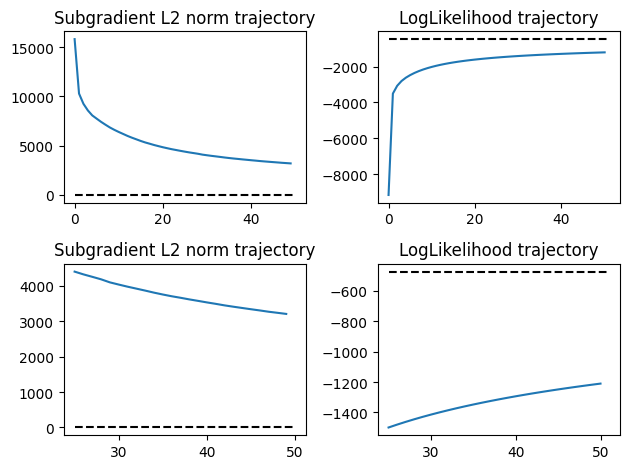

In [331]:
plt.figure()
plt.subplot(221)
plt.plot(np.arange(NITER), params['subgradient_l2_trajectory'])
plt.plot([0, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')


plt.subplot(222)
plt.plot(np.arange(NITER+1), params['loglik_trajectory'])
plt.plot([0, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.subplot(223)
plt.plot(np.arange(NITER//2, NITER), params['subgradient_l2_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')

plt.subplot(224)
plt.plot(np.arange(NITER//2, NITER+1), params['loglik_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.tight_layout()

In [332]:
print(params['open_gap_score'], aligner.open_gap_score)
print(params['extend_gap_score'], aligner.extend_gap_score)

[-1.90709157] -1.0
[-0.20770575] -0.1


In [333]:
params['alpha']

-44.567879331308276

In [334]:
blosum_vs_mine = []
for char1 in params['substitution_matrix'].alphabet:
    for char2 in params['substitution_matrix'].alphabet:
        if char1 != 'N' and char2 != 'N':
            blosum_vs_mine.append([char1, char2,blosum62[char1, char2], params['substitution_matrix'][char1, char2]])

In [335]:
print('Blosum, Mine')
for i in rd.choice(len(blosum_vs_mine), 10, replace=False):
    print(blosum_vs_mine[i])

Blosum, Mine
['M', 'Y', -0.01662515560179388, -0.7314207883187804]
['G', 'S', 0.0, -0.1622084945113686]
['P', 'G', -0.03325031120358776, -0.0966635860368927]
['T', 'G', -0.03325031120358776, -0.318430782059466]
['A', 'Y', -0.03325031120358776, -0.2122895257976945]
['H', 'M', -0.03325031120358776, 0.2817241247930328]
['E', 'A', -0.01662515560179388, 0.07353925170021357]
['A', 'C', 0.0, 0.2965257647460072]
['M', 'S', -0.01662515560179388, 0.397984359654686]
['L', 'S', -0.03325031120358776, -0.06714113950960687]


In [336]:
np.corrcoef([x[2] for x in blosum_vs_mine], [x[3] for x in blosum_vs_mine])

array([[1.        , 0.14812141],
       [0.14812141, 1.        ]])

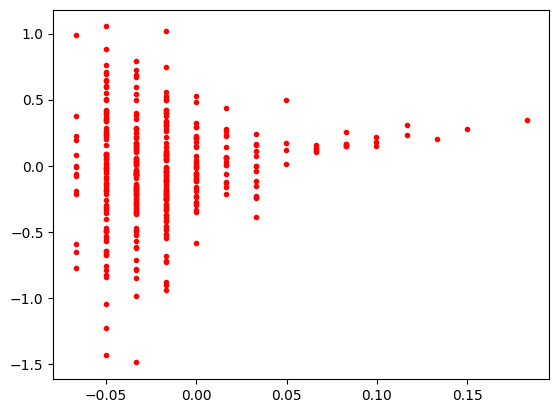

In [337]:
plt.figure()
plt.plot([x[2] for x in blosum_vs_mine], [x[3] for x in blosum_vs_mine], 'r.')

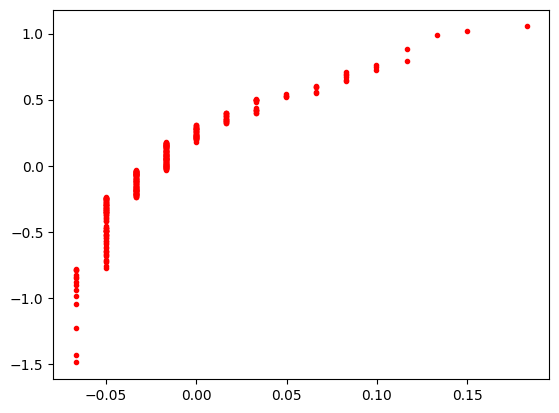

In [338]:
plt.figure()
plt.plot(sorted([x[2] for x in blosum_vs_mine]), sorted([x[3] for x in blosum_vs_mine]), 'r.')